<a href="https://colab.research.google.com/github/pulkitbuilds/Deep-Learning/blob/main/research_feat45.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SE-ResNet on 45 Handcrafted Acoustic Features (ASVspoof 2019)
**Pipeline change:** audio -> 45-D feature vector (extracted **once**, in parallel, cached to disk) -> standardise -> SE-ResNet (dense) -> spoof score.
Everything else (dataset parsing, focal loss, AdamW, cosine warm restarts, AMP, EER/AUC evaluation, checkpointing, plots) is unchanged.

In [1]:
import kagglehub
awsaf49_asvpoof_2019_dataset_path = kagglehub.dataset_download('awsaf49/asvpoof-2019-dataset')

print('Data source import complete.')

100%|██████████| 23.6G/23.6G [04:04<00:00, 104MB/s]

Extracting files...


Data source import complete.


In [3]:
# 1. Colab Package Installation
!pip install soundfile librosa -q

import os, glob, time, json, math, random
import numpy as np, pandas as pd
import soundfile as sf, librosa
import scipy.fftpack as fft_
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, roc_auc_score, precision_recall_curve,
    confusion_matrix, accuracy_score, precision_recall_fscore_support
)
from sklearn.manifold import TSNE
from joblib import Parallel, delayed

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# Set reproducible seeds
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.backends.cudnn.benchmark = True
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_gpus = torch.cuda.device_count()
use_amp = device.type == "cuda"

print(f"Compute Device: {device}")
if use_amp:
    print(f"Available GPUs: {num_gpus}")
    for i in range(num_gpus):
        vram = torch.cuda.get_device_properties(i).total_memory / 1e9
        print(f"   GPU {i}: {torch.cuda.get_device_name(i)} ({vram:.2f} GB VRAM)")

# Updated working directory for Google Colab
fig_dir = "/content/figures"
os.makedirs(fig_dir, exist_ok=True)
print(f"Publication Figures Directory: {fig_dir}")

Compute Device: cpu
Publication Figures Directory: /content/figures


In [4]:
import os

def resolve_dataset():
    # 1. Search typical Colab locations (/content/drive for Google Drive, /content for local, /root/.cache/kagglehub)
    search_dirs = [
        "/content",
        "/content/drive/MyDrive",
        "/content/drive/Shareddrives",
        "/root/.cache/kagglehub/datasets"
    ]

    detected_inputs = []
    for s_dir in search_dirs:
        if os.path.exists(s_dir):
            try:
                items = os.listdir(s_dir)
                detected_inputs.append((s_dir, items))
            except Exception:
                pass

    print("Detected Input Directories:")
    for s_dir, items in detected_inputs:
        print(f"  {s_dir}: {items[:10]}")  # Truncate output to prevent spamming if folders have many files

    found_protos = {"train": None, "dev": None, "eval": None}
    found_flacs = {"train": None, "dev": None, "eval": None}

    # 2. Add common paths where ASVspoof 2019 is typically extracted or saved in Colab
    candidate_roots = [
        "/content/LA/LA",
        "/content/LA",
        "/content/asvspoof2019/LA/LA",
        "/content/asvspoof2019/LA",
        "/content/asvspoof2019",
        "/content/asvpoof-2019-dataset/LA/LA",
        "/content/asvpoof-2019-dataset/LA",
        "/content/drive/MyDrive/asvspoof2019/LA/LA",
        "/content/drive/MyDrive/asvspoof2019/LA",
        "/content/drive/MyDrive/ASVspoof2019/LA/LA",
        "/content/drive/MyDrive/ASVspoof2019/LA",
        "/content/drive/MyDrive/LA/LA",
        "/content/drive/MyDrive/LA",
    ]

    for cand in candidate_roots:
        if os.path.isdir(cand):
            for part, sfx in [("train", "trn"), ("dev", "trl"), ("eval", "trl")]:
                direct_proto = os.path.join(cand, "ASVspoof2019_LA_cm_protocols", f"ASVspoof2019.LA.cm.{part}.{sfx}.txt")
                if os.path.isfile(direct_proto) and not found_protos[part]:
                    found_protos[part] = direct_proto
                direct_flac = os.path.join(cand, f"ASVspoof2019_LA_{part}", "flac")
                if os.path.isdir(direct_flac) and not found_flacs[part]:
                    found_flacs[part] = direct_flac
                elif os.path.isdir(os.path.join(cand, f"ASVspoof2019_LA_{part}")) and not found_flacs[part]:
                    found_flacs[part] = os.path.join(cand, f"ASVspoof2019_LA_{part}")

    # 3. Recursive directory walker if standard candidates fail
    needs_walk = any(v is None for v in [found_protos["train"], found_protos["dev"], found_flacs["train"], found_flacs["dev"]])
    if needs_walk:
        for s_dir in search_dirs:
            if not os.path.exists(s_dir):
                continue
            for root, dirs, files in os.walk(s_dir, followlinks=True):
                for f in files:
                    fl = f.lower()
                    if "cm" in fl and fl.endswith(".txt") and not f.startswith("._"):
                        if "train" in fl and ("trn" in fl or "train" in fl):
                            if not found_protos["train"]:
                                found_protos["train"] = os.path.join(root, f)
                        elif "dev" in fl and ("trl" in fl or "dev" in fl):
                            if not found_protos["dev"]:
                                found_protos["dev"] = os.path.join(root, f)
                        elif "eval" in fl and ("trl" in fl or "eval" in fl):
                            if not found_protos["eval"]:
                                found_protos["eval"] = os.path.join(root, f)

                for d in list(dirs):
                    dl = d.lower()
                    for part in ["train", "dev", "eval"]:
                        if (f"la_{part}" in dl or f"la.{part}" in dl or f"_{part}" in dl) and not found_flacs[part]:
                            sub_flac = os.path.join(root, d, "flac")
                            if os.path.isdir(sub_flac):
                                found_flacs[part] = sub_flac
                            elif os.path.isdir(os.path.join(root, d)):
                                found_flacs[part] = os.path.join(root, d)

                if "flac" in dirs:
                    dirs.remove("flac")

    return found_protos, found_flacs

proto_files, flac_dirs = resolve_dataset()

print("\nResolved Dataset Resources:")
for k in ["train", "dev", "eval"]:
    p_path = proto_files[k]
    f_path = flac_dirs[k]
    p_ok = os.path.isfile(p_path) if p_path else False
    f_ok = os.path.isdir(f_path) if f_path else False
    f_count = len(os.listdir(f_path)) if f_ok else 0
    print(f"  [{k.upper()}] Protocol: {'OK' if p_ok else 'MISSING'} ({p_path})")
    print(f"         Audio:    {'OK' if f_ok else 'MISSING'} ({f_count:,} files in {f_path})")

if not proto_files["train"] or not os.path.isfile(proto_files["train"]):
    print("\nCRITICAL: ASVspoof 2019 dataset not detected in Google Colab environment.")
    print("Action required in Colab:")
    print("Option 1: Download directly via kagglehub:")
    print("          import kagglehub")
    print("          path = kagglehub.dataset_download('awsaf49/asvpoof-2019-dataset')")
    print("Option 2: Mount Google Drive if dataset is saved there:")
    print("          from google.colab import drive; drive.mount('/content/drive')")
    raise FileNotFoundError("Missing ASVspoof 2019 train protocol file in Google Colab.")

if not flac_dirs["train"] or not os.path.isdir(flac_dirs["train"]):
    raise FileNotFoundError("Missing ASVspoof 2019 train audio directory. Please verify dataset location.")

Detected Input Directories:
  /content: ['.config', 'figures', 'sample_data']
  /root/.cache/kagglehub/datasets: ['awsaf49']

Resolved Dataset Resources:
  [TRAIN] Protocol: OK (/root/.cache/kagglehub/datasets/awsaf49/asvpoof-2019-dataset/versions/1/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt)
         Audio:    OK (25,380 files in /root/.cache/kagglehub/datasets/awsaf49/asvpoof-2019-dataset/versions/1/LA/LA/ASVspoof2019_LA_train/flac)
  [DEV] Protocol: OK (/root/.cache/kagglehub/datasets/awsaf49/asvpoof-2019-dataset/versions/1/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt)
         Audio:    OK (24,986 files in /root/.cache/kagglehub/datasets/awsaf49/asvpoof-2019-dataset/versions/1/LA/LA/ASVspoof2019_LA_dev/flac)
  [EVAL] Protocol: OK (/root/.cache/kagglehub/datasets/awsaf49/asvpoof-2019-dataset/versions/1/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt)
         Audio:    OK (71,933 files in /root/.cache/kagglehub/dataset

In [5]:
rows = []
for partition, path in proto_files.items():
    if not path or not os.path.exists(path):
        continue
    flac_folder = flac_dirs.get(partition)
    if not flac_folder or not os.path.exists(flac_folder):
        continue
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            spk, aid, env, atk, key = parts[0], parts[1], parts[2], parts[3], parts[4]
            rows.append({
                "speaker_id": spk,
                "audio_id": aid,
                "environment_id": env,
                "attack_id": atk,
                "key": key,
                "is_spoof": 1 if key == "spoof" else 0,
                "partition": partition,
                "file_path": os.path.join(flac_folder, f"{aid}.flac")
            })

manifest = pd.DataFrame(rows)
assert len(manifest) > 0, "Protocol parsing produced 0 records. Check dataset paths."
print(f"Total Parsed Records: {len(manifest):,}")

summary_table = []
for part in ["train", "dev", "eval"]:
    sub = manifest[manifest["partition"] == part]
    if len(sub) == 0:
        continue
    bon = int((sub["key"] == "bonafide").sum())
    spf = int((sub["key"] == "spoof").sum())
    summary_table.append({
        "Partition": part,
        "Total Utterances": len(sub),
        "Bonafide": bon,
        "Spoof": spf,
        "Spoof:Bonafide Ratio": f"{spf / max(bon, 1):.2f}:1"
    })
print(pd.DataFrame(summary_table).to_string(index=False))

Total Parsed Records: 121,461
Partition  Total Utterances  Bonafide  Spoof Spoof:Bonafide Ratio
    train             25380      2580  22800               8.84:1
      dev             24844      2548  22296               8.75:1
     eval             71237      7355  63882               8.69:1


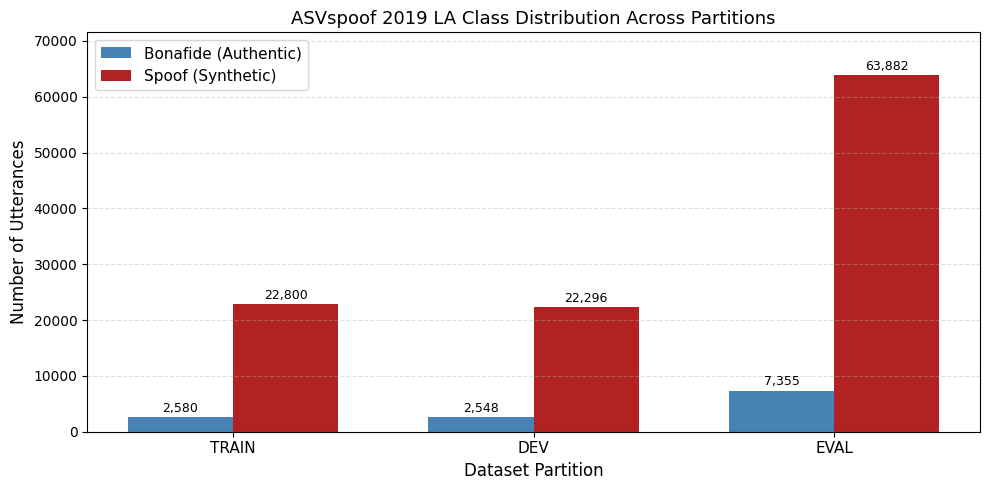

In [6]:
plt.figure(figsize=(10, 5))
partitions = ["train", "dev", "eval"]
bon_counts = [int(((manifest["partition"] == p) & (manifest["key"] == "bonafide")).sum()) for p in partitions]
spf_counts = [int(((manifest["partition"] == p) & (manifest["key"] == "spoof")).sum()) for p in partitions]

x_pos = np.arange(len(partitions))
width = 0.35

plt.bar(x_pos - width / 2, bon_counts, width, label="Bonafide (Authentic)", color="steelblue")
plt.bar(x_pos + width / 2, spf_counts, width, label="Spoof (Synthetic)", color="firebrick")

plt.xlabel("Dataset Partition", fontsize=12)
plt.ylabel("Number of Utterances", fontsize=12)
plt.title("ASVspoof 2019 LA Class Distribution Across Partitions", fontsize=13)
plt.xticks(x_pos, [p.upper() for p in partitions], fontsize=11)
plt.ylim(0, max(spf_counts) * 1.12)
plt.legend(fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.4)

offset = max(spf_counts) * 0.015
for i in range(len(partitions)):
    plt.text(x_pos[i] - width / 2, bon_counts[i] + offset, f"{bon_counts[i]:,}", ha="center", fontsize=9)
    plt.text(x_pos[i] + width / 2, spf_counts[i] + offset, f"{spf_counts[i]:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "01_class_distribution_breakdown.png"), dpi=300, bbox_inches="tight")
plt.show()

Unique Speakers - Train: 20 | Dev: 20 | Eval: 67
Speaker Overlap (Train & Dev):  0 (Expected: 0)
Speaker Overlap (Train & Eval): 0 (Expected: 0)
Speaker Overlap (Dev & Eval):   0 (Expected: 0)


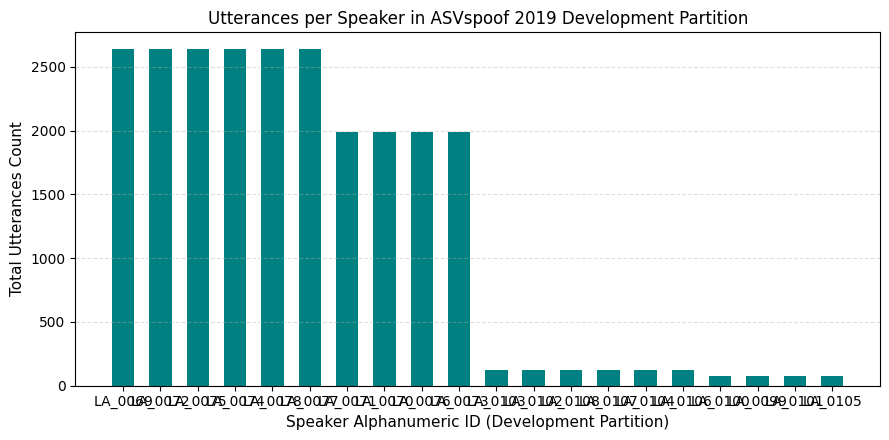

In [7]:
train_spks = set(manifest[manifest["partition"] == "train"]["speaker_id"].unique())
dev_spks = set(manifest[manifest["partition"] == "dev"]["speaker_id"].unique())
eval_spks = set(manifest[manifest["partition"] == "eval"]["speaker_id"].unique())

print(f"Unique Speakers - Train: {len(train_spks)} | Dev: {len(dev_spks)} | Eval: {len(eval_spks)}")
overlap_train_dev = train_spks.intersection(dev_spks)
overlap_train_eval = train_spks.intersection(eval_spks)
overlap_dev_eval = dev_spks.intersection(eval_spks)

print(f"Speaker Overlap (Train & Dev):  {len(overlap_train_dev)} (Expected: 0)")
print(f"Speaker Overlap (Train & Eval): {len(overlap_train_eval)} (Expected: 0)")
print(f"Speaker Overlap (Dev & Eval):   {len(overlap_dev_eval)} (Expected: 0)")
assert len(overlap_train_dev) == 0 and len(overlap_train_eval) == 0

dev_sub = manifest[manifest["partition"] == "dev"]
spk_counts = dev_sub["speaker_id"].value_counts()

plt.figure(figsize=(9, 4.5))
plt.bar(spk_counts.index, spk_counts.values, color="teal", width=0.6)
plt.xlabel("Speaker Alphanumeric ID (Development Partition)", fontsize=11)
plt.ylabel("Total Utterances Count", fontsize=11)
plt.title("Utterances per Speaker in ASVspoof 2019 Development Partition", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "02_speaker_utterance_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()

SEARCHING FOR VALID AUDIO SAMPLES
Bonafide candidates : 2,580
Spoof candidates    : 22,800

VALID AUDIO SAMPLES

BONAFIDE
File       : /root/.cache/kagglehub/datasets/awsaf49/asvpoof-2019-dataset/versions/1/LA/LA/ASVspoof2019_LA_train/flac/LA_T_1138215.flac
Audio ID   : LA_T_1138215
Speaker ID : LA_0079
Sample Rate: 16,000 Hz
Samples    : 55,329
Duration   : 3.46 sec

SPOOF
File       : /root/.cache/kagglehub/datasets/awsaf49/asvpoof-2019-dataset/versions/1/LA/LA/ASVspoof2019_LA_train/flac/LA_T_1004644.flac
Audio ID   : LA_T_1004644
Attack ID  : A01
Sample Rate: 16,000 Hz
Samples    : 30,769
Duration   : 1.92 sec

Files skipped while searching:
Bonafide   : 0
Spoof      : 0


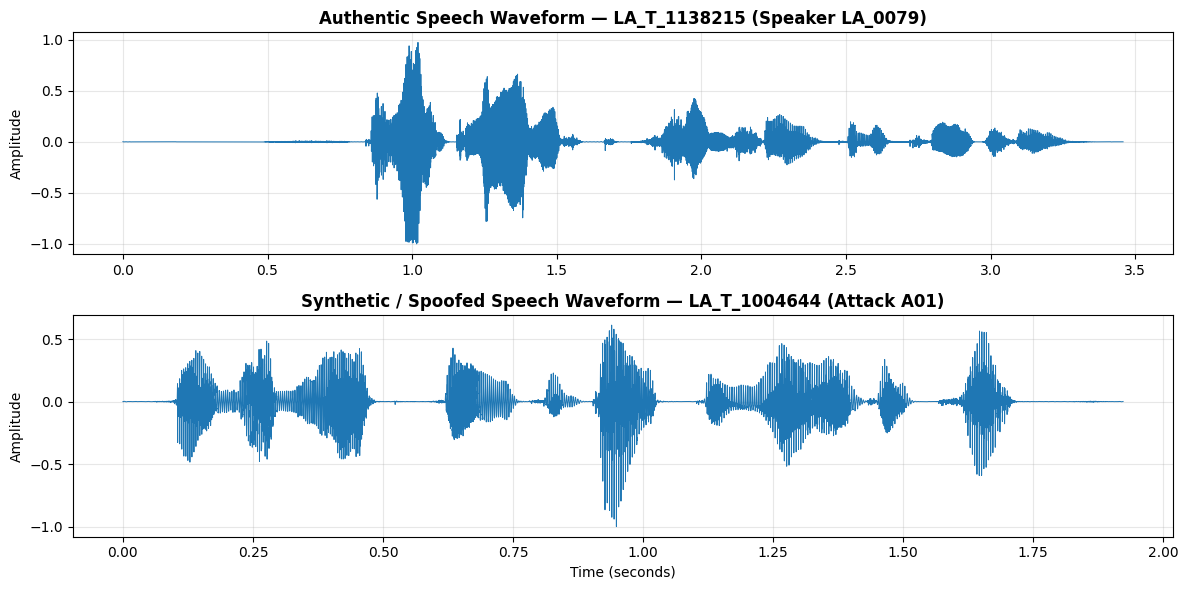


FIGURE SAVED
/content/figures/04_raw_waveform_comparison.png
Resolution: 300 DPI


In [8]:
import os
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt

def find_valid_audio(candidates, label="audio"):
    """
    Search candidate rows and return the first audio file
    that exists and can be successfully decoded by soundfile.
    """

    skipped = 0

    for _, row in candidates.iterrows():

        path = row["file_path"]

        # Check that file exists
        if not os.path.isfile(path):
            skipped += 1
            continue

        try:
            # Attempt actual decoding
            y, sr = sf.read(
                path,
                dtype="float32"
            )

            # Reject empty audio
            if y is None or len(y) == 0:
                skipped += 1
                continue

            # Convert stereo / multichannel -> mono
            if y.ndim > 1:
                y = y.mean(axis=1)

            # Basic validity check
            if not np.all(np.isfinite(y)):
                skipped += 1
                continue

            return row, y, sr, skipped

        except Exception as e:
            skipped += 1
            print(
                f"[Skipped {label}] "
                f"{os.path.basename(path)}"
            )
            print(f"  Reason: {e}")

    return None, None, None, skipped

bon_candidates = manifest[
    (manifest["partition"] == "train") &
    (manifest["key"] == "bonafide")
].copy()

spf_candidates = manifest[
    (manifest["partition"] == "train") &
    (manifest["key"] == "spoof")
].copy()


print("=" * 70)
print("SEARCHING FOR VALID AUDIO SAMPLES")
print("=" * 70)

print(f"Bonafide candidates : {len(bon_candidates):,}")
print(f"Spoof candidates    : {len(spf_candidates):,}")

sample_bon, y_bon_raw, sr_bon, skipped_bon = find_valid_audio(
    bon_candidates,
    label="bonafide"
)

if sample_bon is None:
    raise RuntimeError(
        "No valid bonafide audio file could be decoded."
    )

sample_spf, y_spf_raw, sr_spf, skipped_spf = find_valid_audio(
    spf_candidates,
    label="spoof"
)
if sample_spf is None:
    raise RuntimeError(
        "No valid spoof audio file could be decoded."
    )
bon_duration = len(y_bon_raw) / sr_bon
spf_duration = len(y_spf_raw) / sr_spf

print("\n" + "=" * 70)
print("VALID AUDIO SAMPLES")
print("=" * 70)

print("\nBONAFIDE")
print(f"File       : {sample_bon['file_path']}")
print(f"Audio ID   : {sample_bon['audio_id']}")
print(f"Speaker ID : {sample_bon['speaker_id']}")
print(f"Sample Rate: {sr_bon:,} Hz")
print(f"Samples    : {len(y_bon_raw):,}")
print(f"Duration   : {bon_duration:.2f} sec")

print("\nSPOOF")
print(f"File       : {sample_spf['file_path']}")
print(f"Audio ID   : {sample_spf['audio_id']}")
print(f"Attack ID  : {sample_spf['attack_id']}")
print(f"Sample Rate: {sr_spf:,} Hz")
print(f"Samples    : {len(y_spf_raw):,}")
print(f"Duration   : {spf_duration:.2f} sec")

print("\nFiles skipped while searching:")
print(f"Bonafide   : {skipped_bon}")
print(f"Spoof      : {skipped_spf}")

t_bon = np.arange(len(y_bon_raw)) / sr_bon
t_spf = np.arange(len(y_spf_raw)) / sr_spf

fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 6),
    sharex=False
)
axes[0].plot(
    t_bon,
    y_bon_raw,
    lw=0.7
)
axes[0].set_title(
    f"Authentic Speech Waveform — "
    f"{sample_bon['audio_id']} "
    f"(Speaker {sample_bon['speaker_id']})",
    fontsize=12,
    fontweight="bold"
)
axes[0].set_ylabel(
    "Amplitude",
    fontsize=10
)
axes[0].grid(
    True,
    alpha=0.3
)
axes[1].plot(
    t_spf,
    y_spf_raw,
    lw=0.7
)
axes[1].set_title(
    f"Synthetic / Spoofed Speech Waveform — "
    f"{sample_spf['audio_id']} "
    f"(Attack {sample_spf['attack_id']})",
    fontsize=12,
    fontweight="bold"
)

axes[1].set_xlabel(
    "Time (seconds)",
    fontsize=10
)
axes[1].set_ylabel(
    "Amplitude",
    fontsize=10
)
axes[1].grid(
    True,
    alpha=0.3
)
plt.tight_layout()
os.makedirs(
    fig_dir,
    exist_ok=True
)
output_path = os.path.join(
    fig_dir,
    "04_raw_waveform_comparison.png"
)
plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)
plt.show()
print("\n" + "=" * 70)
print("FIGURE SAVED")
print("=" * 70)
print(output_path)
print(f"Resolution: 300 DPI")

## Preprocessing + 45-feature extraction

In [9]:
SR = 16000

def load_raw_audio(path, target_sr=SR):
    try:
        y, sr = sf.read(path, dtype="float32")
        if y.ndim > 1:
            y = y.mean(axis=1)
    except Exception:
        y, sr = librosa.load(path, sr=None, mono=True)
    if sr != target_sr:
        y = librosa.resample(y, orig_sr=sr, target_sr=target_sr)
    return y.astype(np.float32)

def preprocess_audio(y, is_train=False, target_len=64000, alpha=0.97, top_db=40):
    y = np.concatenate([[y[0]], y[1:] - alpha * y[:-1]])
    intervals = librosa.effects.split(y=y, top_db=top_db)
    if len(intervals):
        trimmed = np.concatenate([y[s:e] for s, e in intervals])
        if len(trimmed) > 1000:
            y = trimmed
    n = len(y)
    if n >= target_len:
        start = np.random.randint(0, n - target_len + 1) if is_train else (n - target_len) // 2
        y = y[start:start + target_len]
    else:
        y = np.pad(y, (0, target_len - n), mode="wrap")
    return y / (np.max(np.abs(y)) + 1e-7)

# ---- The 45-feature layout (edit here if your research uses a different set) ----
N_MFCC = 13
FEATURE_NAMES = (
    [f"mfcc{i+1}_mean" for i in range(N_MFCC)] +          # 13
    [f"mfcc{i+1}_std"  for i in range(N_MFCC)] +          # 13  -> 26
    ["centroid_mean", "centroid_std",
     "bandwidth_mean", "bandwidth_std",
     "rolloff_mean", "rolloff_std",
     "flatness_mean", "flatness_std"] +                   # 8   -> 34
    [f"contrast_b{i}_mean" for i in range(7)] +           # 7   -> 41
    ["zcr_mean", "zcr_std", "rms_mean", "rms_std"]        # 4   -> 45
)
N_FEATURES = len(FEATURE_NAMES)
assert N_FEATURES == 45

def extract_features_45(y, sr=SR, n_fft=1024, hop=256):
    """One STFT shared by every feature (much faster than calling each librosa function on raw audio)."""
    S_mag = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop))
    mel = librosa.feature.melspectrogram(S=S_mag ** 2, sr=sr, n_mels=128, fmin=20, fmax=8000)
    mfcc = librosa.feature.mfcc(S=librosa.power_to_db(mel), n_mfcc=N_MFCC)
    cen = librosa.feature.spectral_centroid(S=S_mag, sr=sr)
    bw = librosa.feature.spectral_bandwidth(S=S_mag, sr=sr)
    ro = librosa.feature.spectral_rolloff(S=S_mag, sr=sr)
    fl = librosa.feature.spectral_flatness(S=S_mag)
    con = librosa.feature.spectral_contrast(S=S_mag, sr=sr, n_bands=6, fmin=100)
    zcr = librosa.feature.zero_crossing_rate(y, frame_length=n_fft, hop_length=hop)
    rms = librosa.feature.rms(S=S_mag, frame_length=n_fft)
    ms = lambda a: [a.mean(), a.std()]
    v = np.concatenate([mfcc.mean(1), mfcc.std(1), ms(cen), ms(bw), ms(ro), ms(fl),
                        con.mean(1), ms(zcr), ms(rms)]).astype(np.float32)
    return v

def file_to_features(path):
    try:
        v = extract_features_45(preprocess_audio(load_raw_audio(path), is_train=False))
        return v if np.isfinite(v).all() else None
    except Exception:
        return None

fv_bon = extract_features_45(preprocess_audio(load_raw_audio(sample_bon["file_path"])))
fv_spf = extract_features_45(preprocess_audio(load_raw_audio(sample_spf["file_path"])))
print(f"Feature vector shape: {fv_bon.shape} (Expected: (45,))")
assert fv_bon.shape == (45,)
print(pd.DataFrame({"feature": FEATURE_NAMES, "bonafide": fv_bon, "spoof": fv_spf}).head(10).to_string(index=False))

Feature vector shape: (45,) (Expected: (45,))
    feature    bonafide       spoof
 mfcc1_mean -376.394226 -362.109131
 mfcc2_mean  -34.826534   23.231421
 mfcc3_mean  -44.966679  -70.535019
 mfcc4_mean    3.575945   26.753656
 mfcc5_mean  -44.443348  -52.044975
 mfcc6_mean   -6.738817   -4.230933
 mfcc7_mean  -14.329025  -28.216812
 mfcc8_mean   -7.154727  -13.343361
 mfcc9_mean   -3.319252   -7.305096
mfcc10_mean  -16.771732  -14.126543


## Extract once, cache to disk (parallel across all CPU cores)

In [10]:
import os
import time
import numpy as np
from joblib import Parallel, delayed

# Updated cache directory for Google Colab workspace (/content)
cache_path = "/content/features_45.npz"

train_df = manifest[manifest["partition"] == "train"].reset_index(drop=True)
dev_df   = manifest[manifest["partition"] == "dev"].reset_index(drop=True)

def extract_split(df, n_jobs=-1):
    out = Parallel(n_jobs=n_jobs, batch_size=64, verbose=0)(
        delayed(file_to_features)(p) for p in df["file_path"].values
    )
    ok = np.array([o is not None for o in out])
    X = np.stack([o for o in out if o is not None]).astype(np.float32)
    return X, ok

t0 = time.time()
if os.path.exists(cache_path):
    z = np.load(cache_path)
    X_train, X_dev, ok_train, ok_dev = z["X_train"], z["X_dev"], z["ok_train"], z["ok_dev"]
    print(f"Loaded cached features from {cache_path}")
else:
    print("Extracting features (one-time cost)...")
    X_train, ok_train = extract_split(train_df)
    X_dev,   ok_dev   = extract_split(dev_df)
    np.savez_compressed(cache_path, X_train=X_train, X_dev=X_dev, ok_train=ok_train, ok_dev=ok_dev)

train_df = train_df[ok_train].reset_index(drop=True)
dev_df   = dev_df[ok_dev].reset_index(drop=True)
y_train  = train_df["is_spoof"].values.astype(np.int64)
y_dev    = dev_df["is_spoof"].values.astype(np.int64)
print(f"Done in {time.time()-t0:.0f}s | train {X_train.shape} | dev {X_dev.shape} | dropped: "
      f"{(~ok_train).sum()} train, {(~ok_dev).sum()} dev")

# Standardise with TRAIN statistics only (no leakage)
feat_mean = X_train.mean(0, keepdims=True)
feat_std  = X_train.std(0, keepdims=True) + 1e-6
Xtr = ((X_train - feat_mean) / feat_std).astype(np.float32)
Xdv = ((X_dev   - feat_mean) / feat_std).astype(np.float32)

Extracting features (one-time cost)...
Done in 1087s | train (25380, 45) | dev (24844, 45) | dropped: 0 train, 0 dev


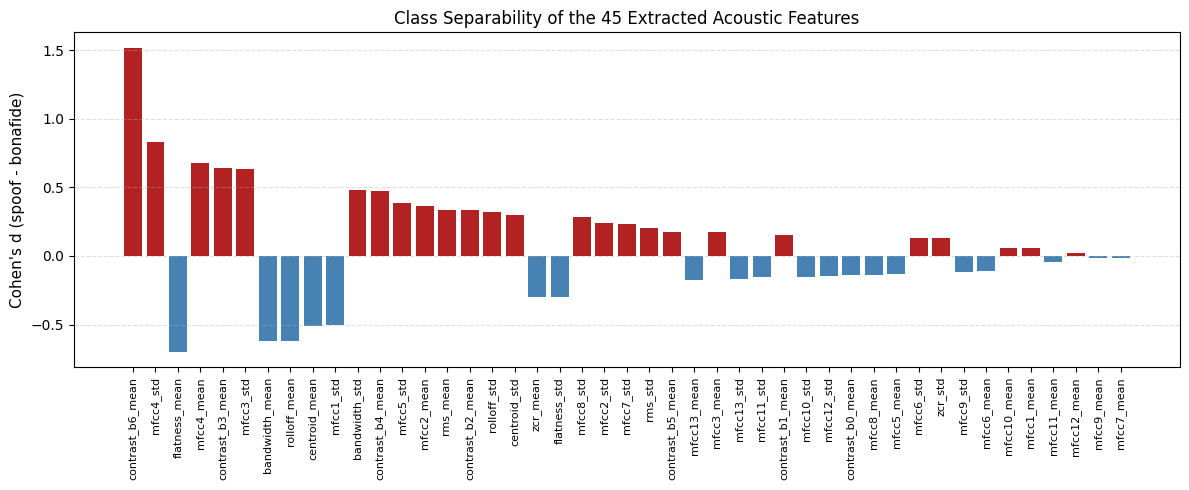

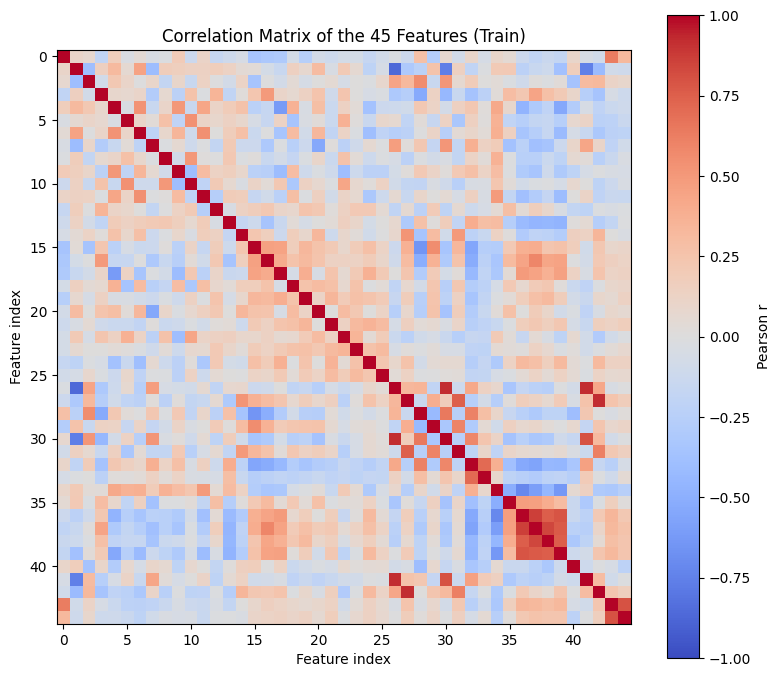

In [11]:
# Figure 03: how well each of the 45 features separates bonafide from spoof (Cohen's d, train set)
b, s = Xtr[y_train == 0], Xtr[y_train == 1]
pooled = np.sqrt((b.var(0) + s.var(0)) / 2) + 1e-8
effect = (s.mean(0) - b.mean(0)) / pooled
order = np.argsort(-np.abs(effect))

plt.figure(figsize=(12, 5))
plt.bar(np.arange(45), effect[order], color=["firebrick" if e > 0 else "steelblue" for e in effect[order]])
plt.xticks(np.arange(45), [FEATURE_NAMES[i] for i in order], rotation=90, fontsize=8)
plt.ylabel("Cohen's d (spoof - bonafide)", fontsize=11)
plt.title("Class Separability of the 45 Extracted Acoustic Features", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "03_feature_effect_size.png"), dpi=300, bbox_inches="tight")
plt.show()

# Figure 05: feature correlation matrix
plt.figure(figsize=(8, 7))
plt.imshow(np.corrcoef(Xtr.T), cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Pearson r")
plt.title("Correlation Matrix of the 45 Features (Train)", fontsize=12)
plt.xlabel("Feature index"); plt.ylabel("Feature index")
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "05_feature_correlation_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()

## Data on GPU (no DataLoader, no per-epoch disk I/O)

In [12]:
batch_size = 64
Xtr_t = torch.from_numpy(Xtr).to(device); ytr_t = torch.from_numpy(y_train).to(device)
Xdv_t = torch.from_numpy(Xdv).to(device); ydv_t = torch.from_numpy(y_dev).to(device)

def train_batches(bs=batch_size):
    perm = torch.randperm(len(Xtr_t), device=device)
    for i in range(0, len(perm), bs):
        idx = perm[i:i + bs]
        if len(idx) < 2:          # BatchNorm needs >= 2 samples
            continue
        yield Xtr_t[idx], ytr_t[idx]

def augment(x, noise_std=0.05, mask_p=0.05, apply_p=0.5):
    """Feature-space analogue of the old SpecAugment: gaussian jitter + random feature masking (set to mean = 0)."""
    on = (torch.rand(x.size(0), 1, device=x.device) < apply_p).float()
    x = x + on * noise_std * torch.randn_like(x)
    keep = 1.0 - on * (torch.rand_like(x) < mask_p).float()
    return x * keep

num_train_batches = math.ceil(len(Xtr_t) / batch_size)
print(f"Train Batches per Epoch: {num_train_batches:,} | Dev samples: {len(Xdv_t):,}")

Train Batches per Epoch: 397 | Dev samples: 24,844


## Model: SE-ResNet-18 (dense version for a 45-D vector)

In [13]:
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(channels, max(channels // reduction, 4)), nn.ReLU(),
            nn.Linear(max(channels // reduction, 4), channels), nn.Sigmoid())
    def forward(self, x):
        return x * self.fc(x)

class ResBlock(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.body = nn.Sequential(
            nn.Linear(in_dim, out_dim, bias=False), nn.BatchNorm1d(out_dim), nn.ReLU(),
            nn.Linear(out_dim, out_dim, bias=False), nn.BatchNorm1d(out_dim))
        self.se = SEBlock(out_dim)
        self.skip = nn.Identity() if in_dim == out_dim else nn.Sequential(
            nn.Linear(in_dim, out_dim, bias=False), nn.BatchNorm1d(out_dim))
    def forward(self, x):
        return F.relu(self.se(self.body(x)) + self.skip(x))

class SEResNet18(nn.Module):
    def __init__(self, in_features=45, num_classes=2, dropout=0.3):
        super().__init__()
        self.stem   = nn.Sequential(nn.Linear(in_features, 64, bias=False), nn.BatchNorm1d(64), nn.ReLU())
        self.layer1 = nn.Sequential(ResBlock(64, 64),   ResBlock(64, 64))
        self.layer2 = nn.Sequential(ResBlock(64, 128),  ResBlock(128, 128))
        self.layer3 = nn.Sequential(ResBlock(128, 256), ResBlock(256, 256))
        self.fc_latent = nn.Linear(256, 64)
        self.head = nn.Sequential(nn.Dropout(dropout), self.fc_latent, nn.ReLU(), nn.Linear(64, num_classes))

    def trunk(self, x):
        return self.layer3(self.layer2(self.layer1(self.stem(x))))
    def extract_latent(self, x):
        return self.fc_latent(self.trunk(x))
    def forward(self, x):
        return self.head(self.trunk(x))

model = SEResNet18(in_features=N_FEATURES).to(device)
print(f"Total Trainable Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
with torch.no_grad():
    model.eval()
    d = torch.zeros(2, N_FEATURES, device=device)
    print("Logits:", tuple(model(d).shape), "| Latent:", tuple(model.extract_latent(d).shape))

Total Trainable Parameters: 412,018
Logits: (2, 2) | Latent: (2, 64)


In [14]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0, label_smoothing=0.05):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction="none", label_smoothing=self.label_smoothing)
        p_t = torch.exp(-ce_loss)
        alpha_factor = torch.where(targets == 1, self.alpha, 1.0 - self.alpha)
        focal_loss = alpha_factor * ((1.0 - p_t) ** self.gamma) * ce_loss
        return focal_loss.mean()

def calculate_eer(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score, pos_label=1)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fpr - fnr))
    eer_val = float((fpr[idx] + fnr[idx]) / 2)
    optimal_thresh = float(np.clip(thresholds[idx], 0.0, 1.0))
    return eer_val, optimal_thresh

In [15]:
@torch.no_grad()
def evaluate_network(model, X, y, use_amp, bs=8192):
    model.eval()
    scores = []
    for i in range(0, len(X), bs):
        with torch.amp.autocast(device_type=device.type, enabled=use_amp):
            scores.append(torch.softmax(model(X[i:i + bs]).float(), dim=1)[:, 1])
    scores = torch.cat(scores).cpu().numpy()
    targets = y.cpu().numpy()
    eer, thresh = calculate_eer(targets, scores)
    auc = float(roc_auc_score(targets, scores))
    return eer, thresh, auc, scores, targets

## Training (same hyper-parameters, loss, optimiser, scheduler and AMP as before)

In [17]:
epochs = 30
lr_init, lr_min, weight_decay = 5e-4, 1e-6, 1e-4
use_amp = torch.cuda.is_available()

criterion = FocalLoss(alpha=0.75, gamma=2.0, label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr_init, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=lr_min)
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

# Updated save path for Google Colab workspace (/content)
save_dir = "/content"
best_checkpoint_path = os.path.join(save_dir, "se_resnet_feat45_best.pth")
history_path = os.path.join(save_dir, "se_resnet_feat45_history.json")

best_eer, best_auc, best_thresh = float("inf"), 0.0, 0.5
training_history = []

print("=" * 90)
print(f"SE-ResNet-18 on 45 features | {epochs} epochs | Device: {device} | AMP: {use_amp}")
print("=" * 90)

for epoch in range(1, epochs + 1):
    t0 = time.time()
    model.train()

    # 1. OPTIMIZATION: Keep scalar metrics on CPU to prevent unnecessary GPU allocations
    run_loss = 0.0
    n_seen = 0

    for b_idx, (xb, yb) in enumerate(train_batches(), start=1):
        # Move data to GPU if it wasn't already handled in generator
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        xb = augment(xb)

        # 2. OPTIMIZATION: set_to_none=True frees memory faster during backprop
        optimizer.zero_grad(set_to_none=True)

        # Mixed Precision Forward
        with torch.amp.autocast(device_type=device.type, enabled=use_amp):
            outputs = model(xb)
            loss = criterion(outputs.float(), yb)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)

        # Gradient Clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        scaler.step(optimizer)
        scaler.update()
        scheduler.step((epoch - 1) + b_idx / num_train_batches)

        # Accumulate as standard Python float to prevent GPU memory leaks
        batch_sz = xb.size(0)
        run_loss += loss.detach().item() * batch_sz
        n_seen += batch_sz

    train_loss = run_loss / max(n_seen, 1)

    # Validation phase
    val_eer, val_thresh, val_auc, _, _ = evaluate_network(model, Xdv_t, ydv_t, use_amp)
    lr_now = optimizer.param_groups[0]["lr"]
    ep_time = time.time() - t0

    training_history.append({
        "epoch": epoch,
        "train_loss": round(train_loss, 6),
        "val_eer": round(float(val_eer), 6),
        "val_auc": round(float(val_auc), 6),
        "val_thresh": round(float(val_thresh), 6),
        "learning_rate": float(lr_now),
        "time_sec": round(ep_time, 2)
    })

    is_best = val_eer < best_eer
    if is_best:
        best_eer, best_auc, best_thresh = float(val_eer), float(val_auc), float(val_thresh)

        # 3. OPTIMIZATION: Save CPU-tensors in checkpoints to reduce VRAM pressure and cross-device conflicts
        torch.save({
            "epoch": epoch,
            "state_dict": {k: v.cpu() for k, v in model.state_dict().items()},
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "eer": best_eer,
            "auc": best_auc,
            "threshold": best_thresh,
            "train_loss": float(train_loss),
            "learning_rate": float(lr_now),
            "feature_names": FEATURE_NAMES,
            "feat_mean": feat_mean,
            "feat_std": feat_std,
            "model_architecture": "SE-ResNet-18-Feat45"
        }, best_checkpoint_path)

    print(f"Epoch [{epoch:02d}/{epochs}] | Loss {train_loss:.4f} | Dev EER {val_eer*100:.2f}% | "
          f"AUC {val_auc:.4f} | Thr {val_thresh:.4f} | LR {lr_now:.2e} | {ep_time:.1f}s"
          f"{' [NEW BEST]' if is_best else ''}")

# Save training history JSON
with open(history_path, "w", encoding="utf-8") as f:
    json.dump(training_history, f, indent=2)

print("=" * 90)
print(f"Best Dev EER: {best_eer*100:.2f}% | AUC: {best_auc:.4f} | Threshold: {best_thresh:.4f}")
print(f"Model: {best_checkpoint_path}\nHistory: {history_path}")

SE-ResNet-18 on 45 features | 30 epochs | Device: cpu | AMP: False
Epoch [01/30] | Loss 0.0115 | Dev EER 9.19% | AUC 0.9657 | Thr 0.8622 | LR 4.88e-04 | 22.4s [NEW BEST]
Epoch [02/30] | Loss 0.0070 | Dev EER 6.39% | AUC 0.9835 | Thr 0.8714 | LR 4.52e-04 | 13.1s [NEW BEST]
Epoch [03/30] | Loss 0.0057 | Dev EER 6.45% | AUC 0.9776 | Thr 0.8319 | LR 3.97e-04 | 9.8s
Epoch [04/30] | Loss 0.0050 | Dev EER 5.43% | AUC 0.9863 | Thr 0.8892 | LR 3.28e-04 | 10.0s [NEW BEST]
Epoch [05/30] | Loss 0.0045 | Dev EER 5.37% | AUC 0.9868 | Thr 0.8980 | LR 2.51e-04 | 9.0s [NEW BEST]
Epoch [06/30] | Loss 0.0040 | Dev EER 6.08% | AUC 0.9793 | Thr 0.9018 | LR 1.73e-04 | 10.0s
Epoch [07/30] | Loss 0.0036 | Dev EER 5.25% | AUC 0.9868 | Thr 0.8977 | LR 1.04e-04 | 9.9s [NEW BEST]
Epoch [08/30] | Loss 0.0032 | Dev EER 5.22% | AUC 0.9881 | Thr 0.8966 | LR 4.87e-05 | 10.3s [NEW BEST]
Epoch [09/30] | Loss 0.0031 | Dev EER 5.49% | AUC 0.9848 | Thr 0.9083 | LR 1.32e-05 | 9.5s
Epoch [10/30] | Loss 0.0033 | Dev EER 5.38%

## Evaluation and figures

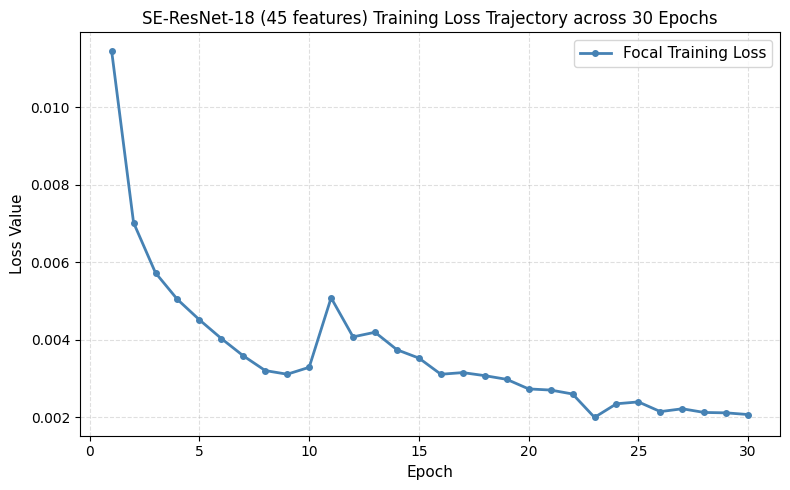

In [18]:
ep_list = [h["epoch"] for h in training_history]
losses = [h["train_loss"] for h in training_history]

plt.figure(figsize=(8, 5))
plt.plot(ep_list, losses, color="steelblue", lw=2, marker="o", ms=4, label="Focal Training Loss")
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("Loss Value", fontsize=11)
plt.title("SE-ResNet-18 (45 features) Training Loss Trajectory across 30 Epochs", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "07_training_loss_trajectory.png"), dpi=300, bbox_inches="tight")
plt.show()

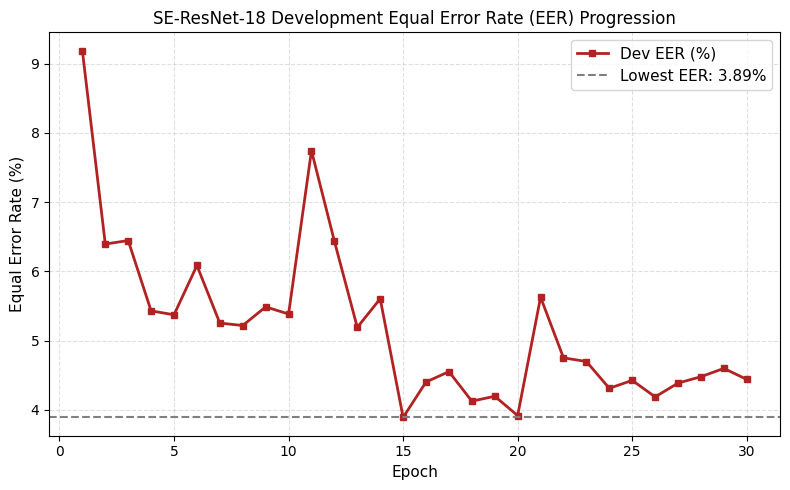

In [19]:
eers = [h["val_eer"] * 100 for h in training_history]

plt.figure(figsize=(8, 5))
plt.plot(ep_list, eers, color="firebrick", lw=2, marker="s", ms=4, label="Dev EER (%)")
plt.axhline(min(eers), color="gray", linestyle="--", label=f"Lowest EER: {min(eers):.2f}%")
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("Equal Error Rate (%)", fontsize=11)
plt.title("SE-ResNet-18 Development Equal Error Rate (EER) Progression", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "08_dev_eer_progression_curve.png"), dpi=300, bbox_inches="tight")
plt.show()

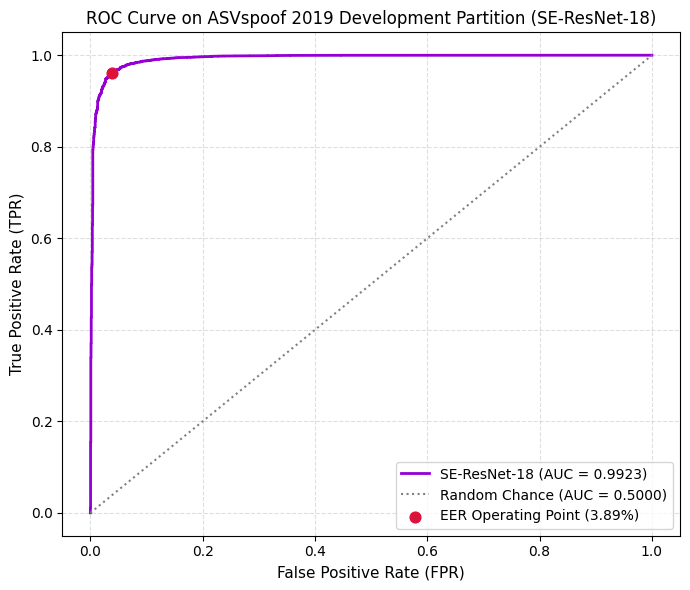

In [20]:
checkpoint = torch.load(best_checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["state_dict"])
_, optimal_thresh, _, final_scores, final_targets = evaluate_network(model, Xdv_t, ydv_t, use_amp)

fpr, tpr, _ = roc_curve(final_targets, final_scores, pos_label=1)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="darkviolet", lw=2, label=f"SE-ResNet-18 (AUC = {checkpoint['auc']:.4f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle=":", label="Random Chance (AUC = 0.5000)")
plt.scatter([checkpoint['eer']], [1 - checkpoint['eer']], color="crimson", s=60, zorder=5, label=f"EER Operating Point ({checkpoint['eer']*100:.2f}%)")
plt.xlabel("False Positive Rate (FPR)", fontsize=11)
plt.ylabel("True Positive Rate (TPR)", fontsize=11)
plt.title("ROC Curve on ASVspoof 2019 Development Partition (SE-ResNet-18)", fontsize=12)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "09_receiver_operating_characteristic_roc.png"), dpi=300, bbox_inches="tight")
plt.show()

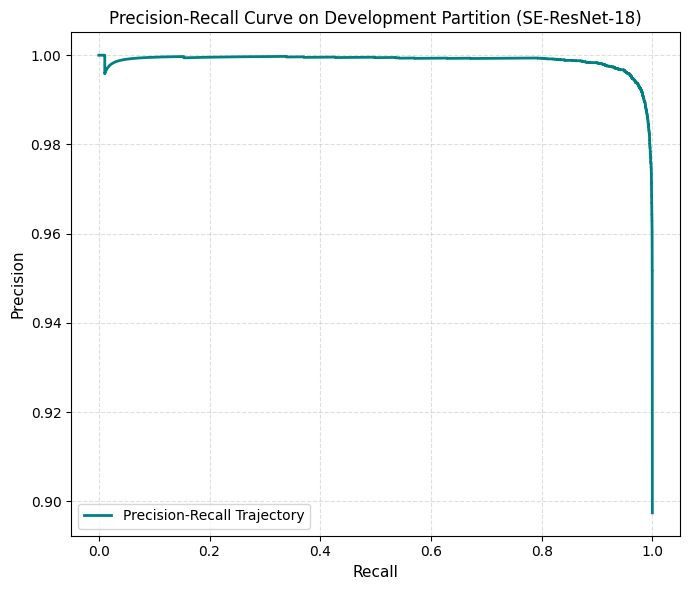

In [21]:
prec, rec, _ = precision_recall_curve(final_targets, final_scores, pos_label=1)

plt.figure(figsize=(7, 6))
plt.plot(rec, prec, color="teal", lw=2, label="Precision-Recall Trajectory")
plt.xlabel("Recall", fontsize=11)
plt.ylabel("Precision", fontsize=11)
plt.title("Precision-Recall Curve on Development Partition (SE-ResNet-18)", fontsize=12)
plt.legend(loc="lower left", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "10_precision_recall_trajectory.png"), dpi=300, bbox_inches="tight")
plt.show()

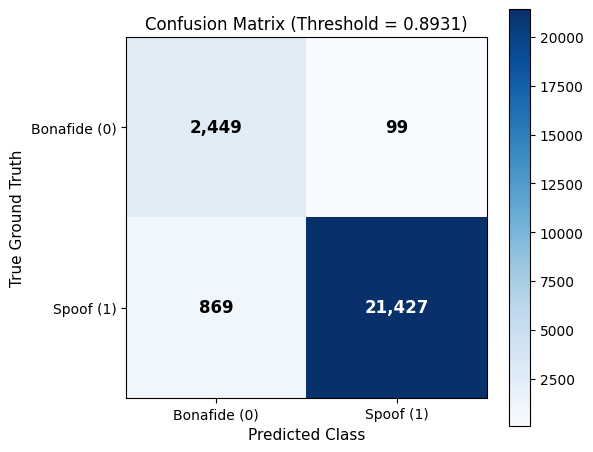

Accuracy:  96.10%
Precision: 99.54%
Recall:    96.10%
F1-Score:  0.9779


In [22]:
predicted_binary = (final_scores >= optimal_thresh).astype(int)
cm = confusion_matrix(final_targets, predicted_binary)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title(f"Confusion Matrix (Threshold = {optimal_thresh:.4f})", fontsize=12)
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ["Bonafide (0)", "Spoof (1)"], fontsize=10)
plt.yticks(tick_marks, ["Bonafide (0)", "Spoof (1)"], fontsize=10)

thresh_val = cm.max() / 2.0
for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > thresh_val else "black"
        plt.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", color=color, fontsize=12, fontweight="bold")

plt.ylabel("True Ground Truth", fontsize=11)
plt.xlabel("Predicted Class", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "11_confusion_matrix_optimal_threshold.png"), dpi=300, bbox_inches="tight")
plt.show()

acc = accuracy_score(final_targets, predicted_binary)
p, r, f1, _ = precision_recall_fscore_support(final_targets, predicted_binary, average="binary")
print(f"Accuracy:  {acc * 100:.2f}%")
print(f"Precision: {p * 100:.2f}%")
print(f"Recall:    {r * 100:.2f}%")
print(f"F1-Score:  {f1:.4f}")

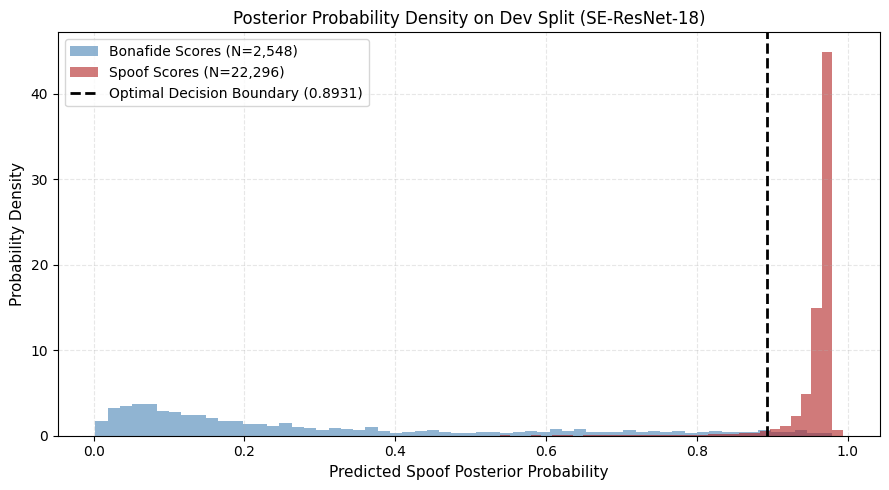

In [23]:
bonafide_scores = final_scores[final_targets == 0]
spoof_scores = final_scores[final_targets == 1]

plt.figure(figsize=(9, 5))
plt.hist(bonafide_scores, bins=60, density=True, alpha=0.6, color="steelblue", label=f"Bonafide Scores (N={len(bonafide_scores):,})")
plt.hist(spoof_scores, bins=60, density=True, alpha=0.6, color="firebrick", label=f"Spoof Scores (N={len(spoof_scores):,})")
plt.axvline(optimal_thresh, color="black", linestyle="--", lw=2, label=f"Optimal Decision Boundary ({optimal_thresh:.4f})")

plt.xlabel("Predicted Spoof Posterior Probability", fontsize=11)
plt.ylabel("Probability Density", fontsize=11)
plt.title("Posterior Probability Density on Dev Split (SE-ResNet-18)", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "12_posterior_probability_density.png"), dpi=300, bbox_inches="tight")
plt.show()

In [24]:
dev_eval_df = dev_df.copy().reset_index(drop=True)
dev_eval_df["spoof_score"] = final_scores
dev_eval_df["predicted_label"] = predicted_binary

attack_mapping = {
    "A01": "TTS: Neural Acoustic (AR RNN) + WaveNet",
    "A02": "TTS: Neural Acoustic (AR RNN) + WORLD",
    "A03": "TTS: Concatenative Unit Selection",
    "A04": "VC: Formant / Pitch Shifting + STRAIGHT",
    "A05": "VC: Variational Autoencoder (VAE)",
    "A06": "VC: Transfer Function Regression + WORLD"
}

breakdown_data = []
for atk_id in ["A01", "A02", "A03", "A04", "A05", "A06"]:
    sub = dev_eval_df[dev_eval_df["attack_id"] == atk_id]
    if len(sub) == 0:
        continue
    correct = int((sub["predicted_label"] == 1).sum())
    detection_acc = correct / len(sub)
    mean_prob = float(sub["spoof_score"].mean())
    breakdown_data.append({
        "Attack ID": atk_id,
        "Algorithm Family": attack_mapping.get(atk_id, "Unknown"),
        "Total Utterances": len(sub),
        "Detection Accuracy (%)": round(detection_acc * 100, 2),
        "Mean Spoof Score": round(mean_prob, 4)
    })

bonafide_sub = dev_eval_df[dev_eval_df["key"] == "bonafide"]
bon_correct = int((bonafide_sub["predicted_label"] == 0).sum())
bon_acc = bon_correct / len(bonafide_sub)
breakdown_data.append({
    "Attack ID": "Bonafide",
    "Algorithm Family": "Authentic Human Speech (VCTK)",
    "Total Utterances": len(bonafide_sub),
    "Detection Accuracy (%)": round(bon_acc * 100, 2),
    "Mean Spoof Score": round(float(bonafide_sub["spoof_score"].mean()), 4)
})

breakdown_df = pd.DataFrame(breakdown_data)
print(breakdown_df.to_string(index=False))

Attack ID                         Algorithm Family  Total Utterances  Detection Accuracy (%)  Mean Spoof Score
      A01  TTS: Neural Acoustic (AR RNN) + WaveNet              3716                   99.25            0.9678
      A02    TTS: Neural Acoustic (AR RNN) + WORLD              3716                   96.77            0.9565
      A03        TTS: Concatenative Unit Selection              3716                   95.32            0.9585
      A04  VC: Formant / Pitch Shifting + STRAIGHT              3716                   96.85            0.9620
      A05        VC: Variational Autoencoder (VAE)              3716                   89.99            0.9362
      A06 VC: Transfer Function Regression + WORLD              3716                   98.44            0.9662
 Bonafide            Authentic Human Speech (VCTK)              2548                   96.11            0.2987


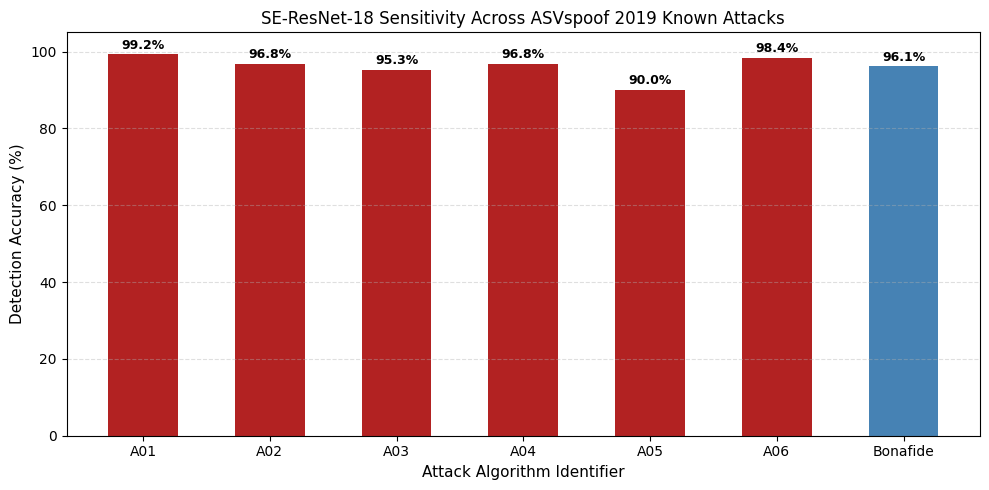

In [25]:
plt.figure(figsize=(10, 5))
attack_labels = breakdown_df["Attack ID"].values
accuracies = breakdown_df["Detection Accuracy (%)"].values
bar_colors = ["firebrick" if a.startswith("A") else "steelblue" for a in attack_labels]

bars = plt.bar(attack_labels, accuracies, color=bar_colors, width=0.55)
plt.xlabel("Attack Algorithm Identifier", fontsize=11)
plt.ylabel("Detection Accuracy (%)", fontsize=11)
plt.title("SE-ResNet-18 Sensitivity Across ASVspoof 2019 Known Attacks", fontsize=12)
plt.ylim(0, 105)
plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, h + 1.5, f"{h:.1f}%", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "13_attack_taxonomy_accuracy_breakdown.png"), dpi=300, bbox_inches="tight")
plt.show()

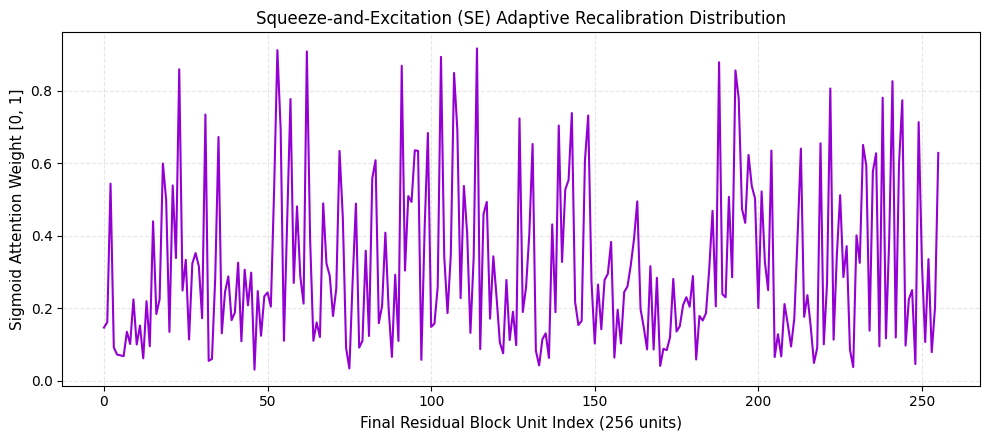

In [26]:
# SE channel recalibration weights (last SE block, layer3[1])
model.eval()
with torch.no_grad():
    h = model.layer3[0](model.layer2(model.layer1(model.stem(Xdv_t[:256]))))
    blk = model.layer3[1]
    channel_weights = blk.se.fc(blk.body(h)).cpu().numpy()
mean_weights = channel_weights.mean(axis=0)

plt.figure(figsize=(10, 4.5))
plt.plot(np.arange(len(mean_weights)), mean_weights, color="darkviolet", lw=1.5)
plt.xlabel("Final Residual Block Unit Index (256 units)", fontsize=11)
plt.ylabel("Sigmoid Attention Weight [0, 1]", fontsize=11)
plt.title("Squeeze-and-Excitation (SE) Adaptive Recalibration Distribution", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "14_squeeze_excitation_channel_weights.png"), dpi=300, bbox_inches="tight")
plt.show()

Extracted Latent Embeddings: (900, 64)


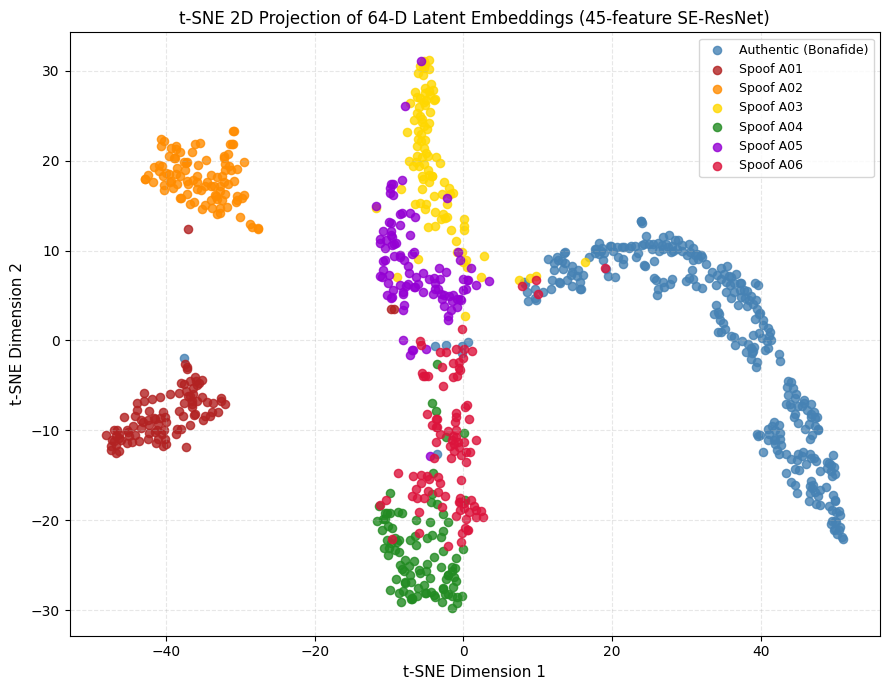

In [27]:
# t-SNE of the 64-D latent space (same sampling scheme as before)
sample_idx = []
for atk in ["A01", "A02", "A03", "A04", "A05", "A06"]:
    sample_idx += dev_eval_df.index[dev_eval_df["attack_id"] == atk].tolist()[:100]
sample_idx += dev_eval_df.index[dev_eval_df["key"] == "bonafide"].tolist()[:300]
sub_df = dev_eval_df.loc[sample_idx].reset_index(drop=True)

model.eval()
with torch.no_grad():
    latent_matrix = model.extract_latent(Xdv_t[torch.tensor(sample_idx, device=device)]).float().cpu().numpy()
print(f"Extracted Latent Embeddings: {latent_matrix.shape}")

coords_2d = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(latent_matrix)
plt.figure(figsize=(9, 7))
is_bon = (sub_df["key"] == "bonafide").values
plt.scatter(coords_2d[is_bon, 0], coords_2d[is_bon, 1], color="steelblue", alpha=0.8, s=35, label="Authentic (Bonafide)")
palette = {"A01": "firebrick", "A02": "darkorange", "A03": "gold", "A04": "forestgreen", "A05": "darkviolet", "A06": "crimson"}
for atk, col in palette.items():
    m = (sub_df["attack_id"] == atk).values
    if m.sum() > 0:
        plt.scatter(coords_2d[m, 0], coords_2d[m, 1], color=col, alpha=0.8, s=35, label=f"Spoof {atk}")
plt.xlabel("t-SNE Dimension 1", fontsize=11); plt.ylabel("t-SNE Dimension 2", fontsize=11)
plt.title("t-SNE 2D Projection of 64-D Latent Embeddings (45-feature SE-ResNet)", fontsize=12)
plt.legend(loc="best", fontsize=9); plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "15_tsne_latent_embedding_clusters.png"), dpi=300, bbox_inches="tight")
plt.show()

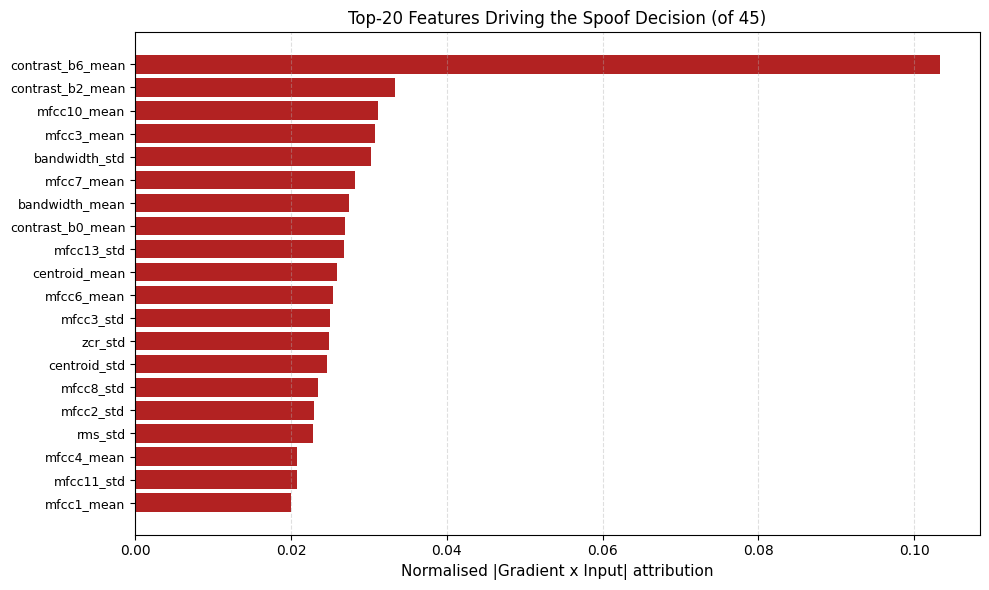

In [28]:
# Feature attribution (replaces Grad-CAM: there is no time-frequency map any more).
# Gradient x Input on dev spoof samples, averaged over |attribution|.
model.eval()
xs = Xdv_t[ydv_t == 1][:2000].clone().requires_grad_(True)
model.zero_grad()
model(xs)[:, 1].sum().backward()
attr = (xs.grad * xs).abs().mean(0).detach().cpu().numpy()
attr = attr / attr.sum()
top = np.argsort(-attr)[:20]

plt.figure(figsize=(10, 6))
plt.barh(np.arange(20)[::-1], attr[top], color="firebrick")
plt.yticks(np.arange(20)[::-1], [FEATURE_NAMES[i] for i in top], fontsize=9)
plt.xlabel("Normalised |Gradient x Input| attribution", fontsize=11)
plt.title("Top-20 Features Driving the Spoof Decision (of 45)", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "16_feature_attribution.png"), dpi=300, bbox_inches="tight")
plt.show()

In [29]:
def predict_audio_file(file_path, target_model, compute_device, threshold):
    target_model.eval()
    v = extract_features_45(preprocess_audio(load_raw_audio(file_path), is_train=False))
    v = (v[None, :] - feat_mean) / feat_std
    x = torch.from_numpy(v.astype(np.float32)).to(compute_device)
    with torch.no_grad():
        prob = torch.softmax(target_model(x).float(), dim=1)[0, 1].item()
    decision = "SPOOF (SYNTHETIC)" if prob >= threshold else "BONAFIDE (AUTHENTIC)"
    confidence = prob if prob >= threshold else 1.0 - prob
    return {"file_name": os.path.basename(file_path), "decision": decision,
            "spoof_probability": round(prob, 5), "confidence": f"{confidence * 100:.2f}%"}

bon_path = dev_df[dev_df["key"] == "bonafide"].iloc[0]["file_path"]
spf_path = dev_df[dev_df["key"] == "spoof"].iloc[0]["file_path"]
print("Case 1: Ground Truth Authentic Speech"); print(json.dumps(predict_audio_file(bon_path, model, device, optimal_thresh), indent=2))
print("\nCase 2: Ground Truth Deepfake Speech"); print(json.dumps(predict_audio_file(spf_path, model, device, optimal_thresh), indent=2))

Case 1: Ground Truth Authentic Speech
{
  "file_name": "LA_D_1047731.flac",
  "decision": "BONAFIDE (AUTHENTIC)",
  "spoof_probability": 0.22804,
  "confidence": "77.20%"
}

Case 2: Ground Truth Deepfake Speech
{
  "file_name": "LA_D_1008730.flac",
  "decision": "SPOOF (SYNTHETIC)",
  "spoof_probability": 0.97049,
  "confidence": "97.05%"
}


In [31]:

# Set save_dir to Colab's default working folder if not already defined
save_dir = "/content"

print(f"Generated Scientific Artifacts in {save_dir}:")
print("-" * 65)
for root_path, _, files in os.walk(save_dir):
    for f in sorted(files):
        full_fpath = os.path.join(root_path, f)
        rel_fpath = os.path.relpath(full_fpath, save_dir)
        size_kb = os.path.getsize(full_fpath) / 1024
        print(f"  {rel_fpath:<45} | {size_kb:>9.1f} KB")

Generated Scientific Artifacts in /content:
-----------------------------------------------------------------
  features_45.npz                               |    8265.7 KB
  se_resnet_feat45_best.pth                     |    4945.2 KB
  se_resnet_feat45_history.json                 |       5.7 KB
  .config/.last_opt_in_prompt.yaml              |       0.0 KB
  .config/.last_survey_prompt.yaml              |       0.0 KB
  .config/.last_update_check.json               |       0.1 KB
  .config/active_config                         |       0.0 KB
  .config/config_sentinel                       |       0.0 KB
  .config/default_configs.db                    |      12.0 KB
  .config/gce                                   |       0.0 KB
  .config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db |      12.0 KB
  .config/configurations/config_default         |       0.1 KB
  .config/logs/2026.09.16/13.25.37.877256.log   |      52.0 KB
  .config/logs/2026.09.16/13.26.04.283691.log 

In [32]:
from google.colab import files

# Zip all generated models, json logs, and figures
!zip -r /content/artifacts.zip /content/*.pth /content/*.json /content/figures/

# Trigger direct download in your browser
files.download('/content/artifacts.zip')

  adding: content/se_resnet_feat45_best.pth (deflated 9%)
  adding: content/se_resnet_feat45_history.json (deflated 82%)
  adding: content/figures/ (stored 0%)
  adding: content/figures/05_feature_correlation_matrix.png (deflated 25%)
  adding: content/figures/10_precision_recall_trajectory.png (deflated 22%)
  adding: content/figures/02_speaker_utterance_distribution.png (deflated 20%)
  adding: content/figures/11_confusion_matrix_optimal_threshold.png (deflated 18%)
  adding: content/figures/15_tsne_latent_embedding_clusters.png (deflated 7%)
  adding: content/figures/08_dev_eer_progression_curve.png (deflated 15%)
  adding: content/figures/14_squeeze_excitation_channel_weights.png (deflated 4%)
  adding: content/figures/03_feature_effect_size.png (deflated 21%)
  adding: content/figures/13_attack_taxonomy_accuracy_breakdown.png (deflated 22%)
  adding: content/figures/04_raw_waveform_comparison.png (deflated 8%)
  adding: content/figures/12_posterior_probability_density.png (deflate

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
from google.colab import drive
drive.mount('/content/drive')

# Create a destination directory in Google Drive
!mkdir -p /content/drive/MyDrive/ASVspoof_Results/

# Copy all models, figures, and history files
!cp -r /content/*.pth /content/*.json /content/figures /content/drive/MyDrive/ASVspoof_Results/
print("Successfully backed up all artifacts to Google Drive!")

Mounted at /content/drive
Successfully backed up all artifacts to Google Drive!
